In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
credit_data = pd.read_csv('Datasets/credit_train.csv')
credit_data.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,"445,412",Short Term,709,"1,167,493",8 years,Home Mortgage,Home Improvements,"5,214.74",17.2,NaN,6,1,"228,190","416,746",1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,"262,328",Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,"33,295.98",21.1,8.0,35,0,"229,976","850,784",0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,"99,999,999",Short Term,741,"2,231,892",8 years,Own Home,Debt Consolidation,"29,200.53",14.9,29.0,18,1,"297,996","750,090",0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,"347,666",Long Term,721,"806,949",3 years,Own Home,Debt Consolidation,"8,741.90",12.0,NaN,9,0,"256,329","386,958",0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,"176,220",Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,"20,639.70",6.1,NaN,15,0,"253,460","427,174",0.0,0.0


In [3]:
credit_data = credit_data.drop_duplicates()
credit_data = credit_data.dropna()
credit_data = credit_data.sample(5000)

In [14]:
credit_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Years of Credit History,100000.0,18.199141,7.015324,3.6,13.5,16.9,21.7,70.5
Months since last delinquent,46859.0,34.901321,21.997829,0.0,16.0,32.0,51.0,176.0
Number of Open Accounts,100000.0,11.128530,5.009870,0.0,8.0,10.0,14.0,76.0
Number of Credit Problems,100000.0,0.168310,0.482705,0.0,0.0,0.0,0.0,15.0
Bankruptcies,99796.0,0.117740,0.351424,0.0,0.0,0.0,0.0,7.0
Tax Liens,99990.0,0.029313,0.258182,0.0,0.0,0.0,0.0,15.0


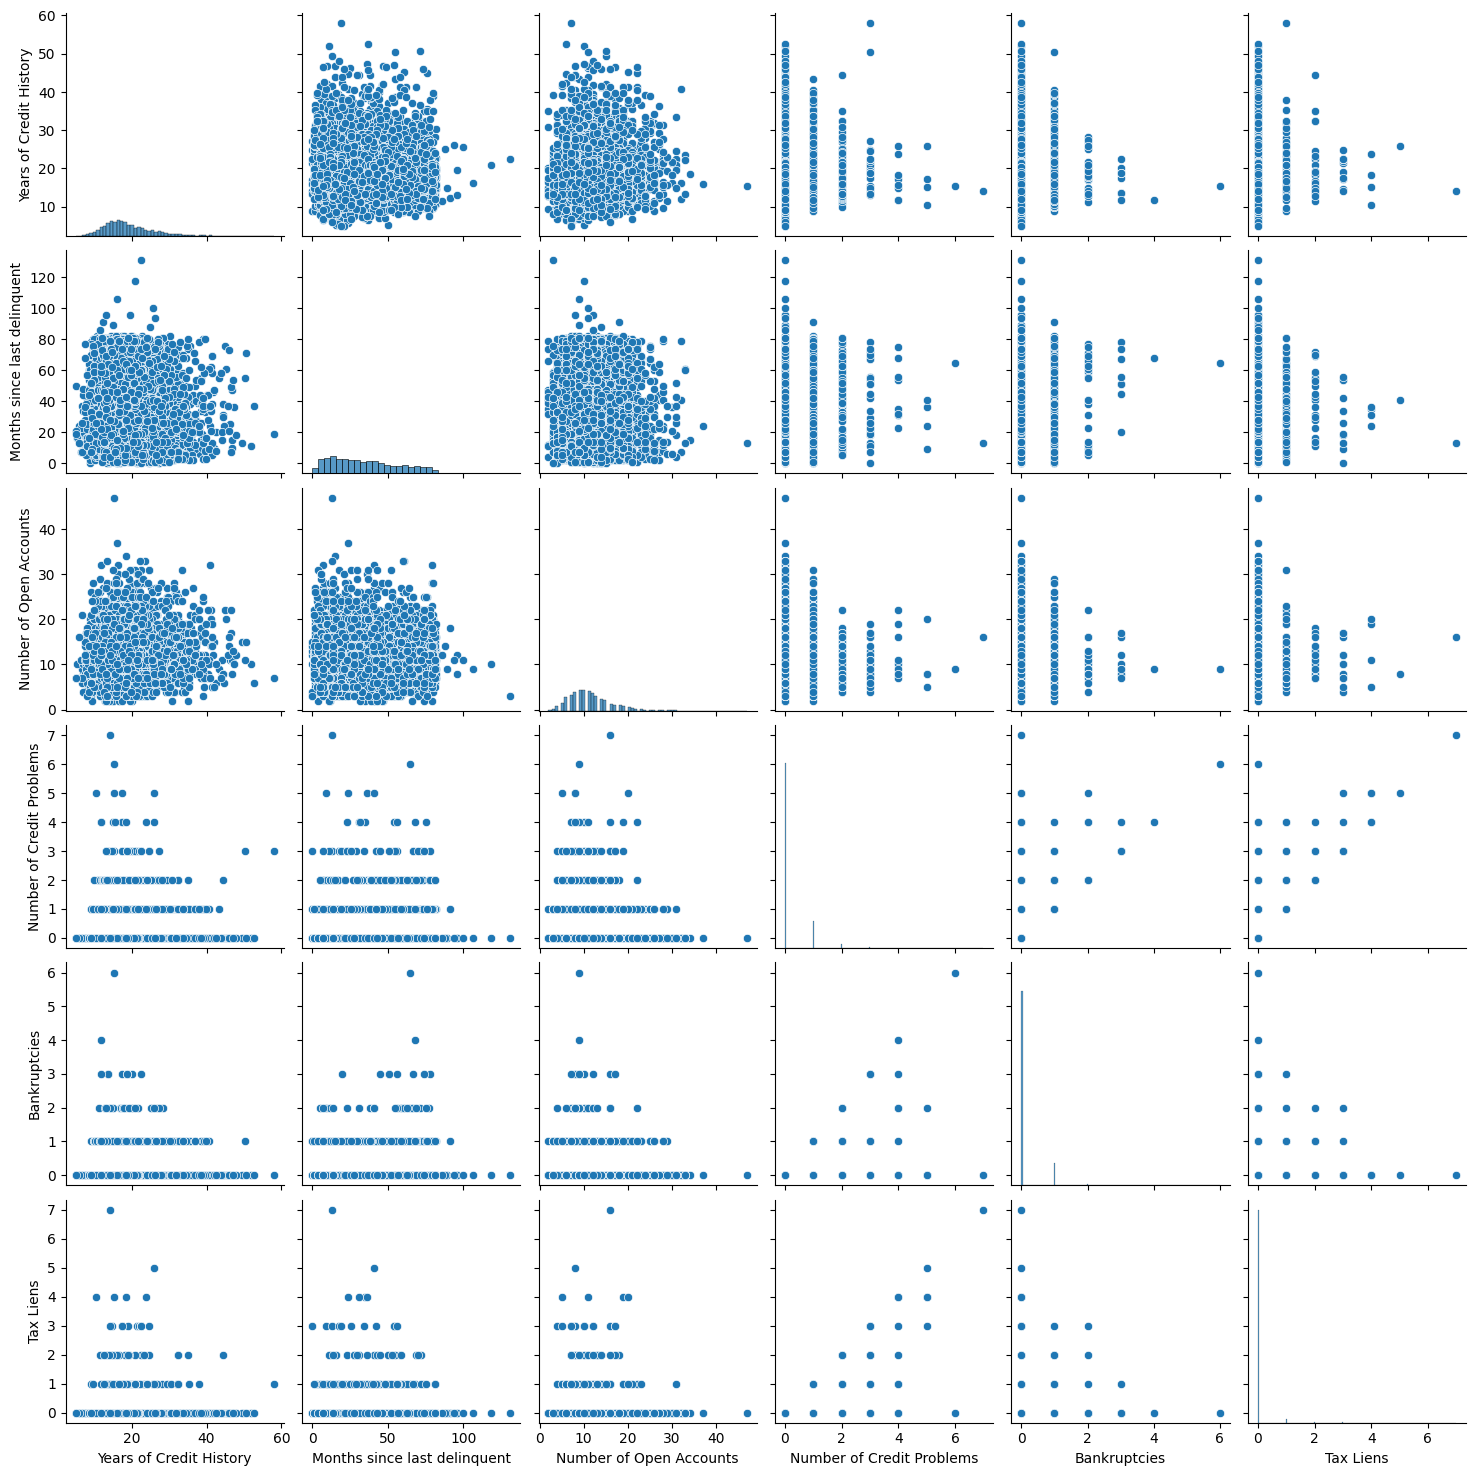

In [5]:
sns.pairplot(credit_data)

In [15]:
# Converting the list
credit_data['MonthlyDebt'] = (
    credit_data['Monthly Debt']
    .str.replace(',', '', regex=False)
    .astype(float)
)

credit_data['AnnualIncome'] = credit_data['Annual Income'].str.replace(',', '', regex=True).astype(int)



ValueError: cannot convert float NaN to integer

In [16]:
credit_data['Current Credit Balance'] = (
    credit_data['Current Credit Balance']
    .replace({',': ''}, regex=True)   # remove commas if present
    .replace({'\$':'', '£':'', '€':''}, regex=True)  # remove currency symbols
    .str.strip()                      # remove spaces
)

credit_data['Current Credit Balance'] = pd.to_numeric(
    credit_data['Current Credit Balance'],
    errors='coerce'
)

KeyError: 'AnnualIncome'

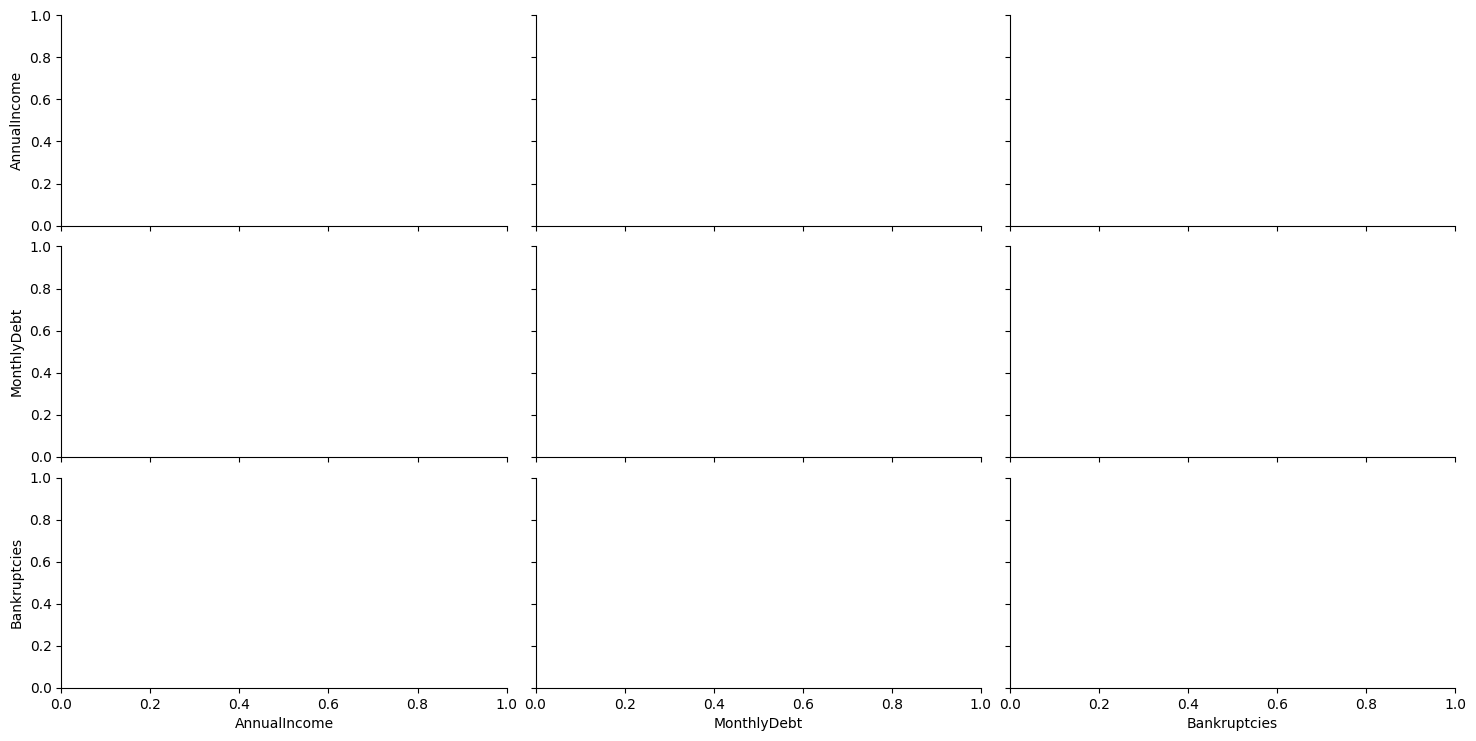

In [17]:
sns.pairplot(credit_data,
             vars = ['AnnualIncome', 'MonthlyDebt', 'Bankruptcies'],
             aspect=2)

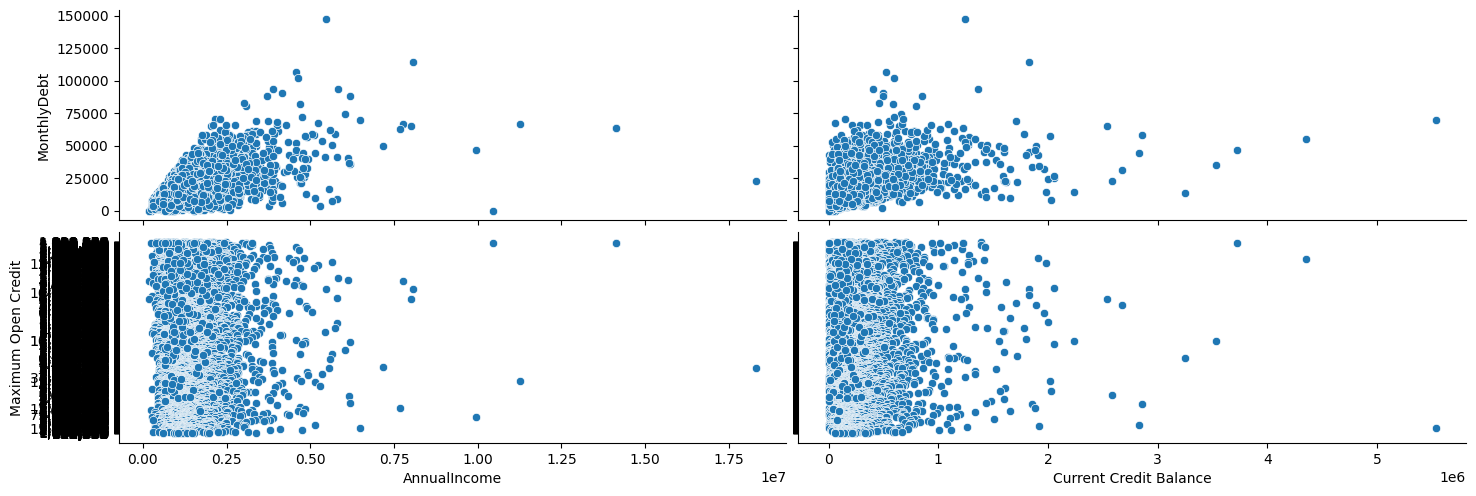

In [27]:
sns.pairplot(credit_data,
             x_vars=['AnnualIncome', 'Current Credit Balance'],
             y_vars=['MonthlyDebt', 'Maximum Open Credit'],
             diag_kind = None, aspect=3) 

KeyError: 'AnnualIncome'

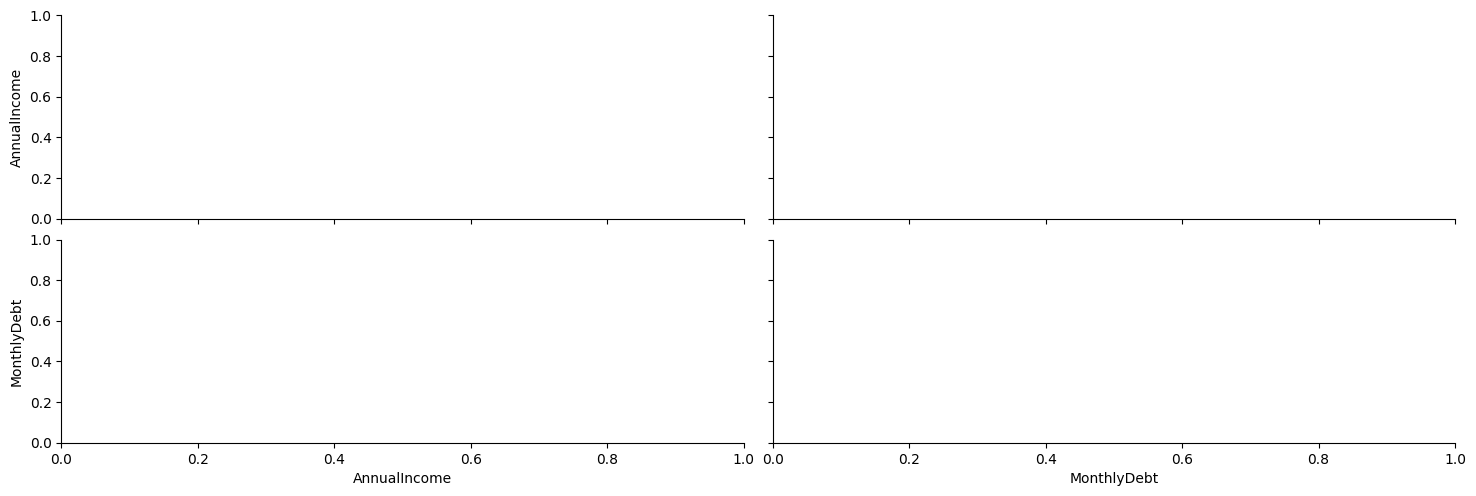

In [18]:
# Customizing The Pair Plot  
sns.pairplot(credit_data, vars = ['AnnualIncome', 'MonthlyDebt'], diag_kind = 'kde', aspect=3)

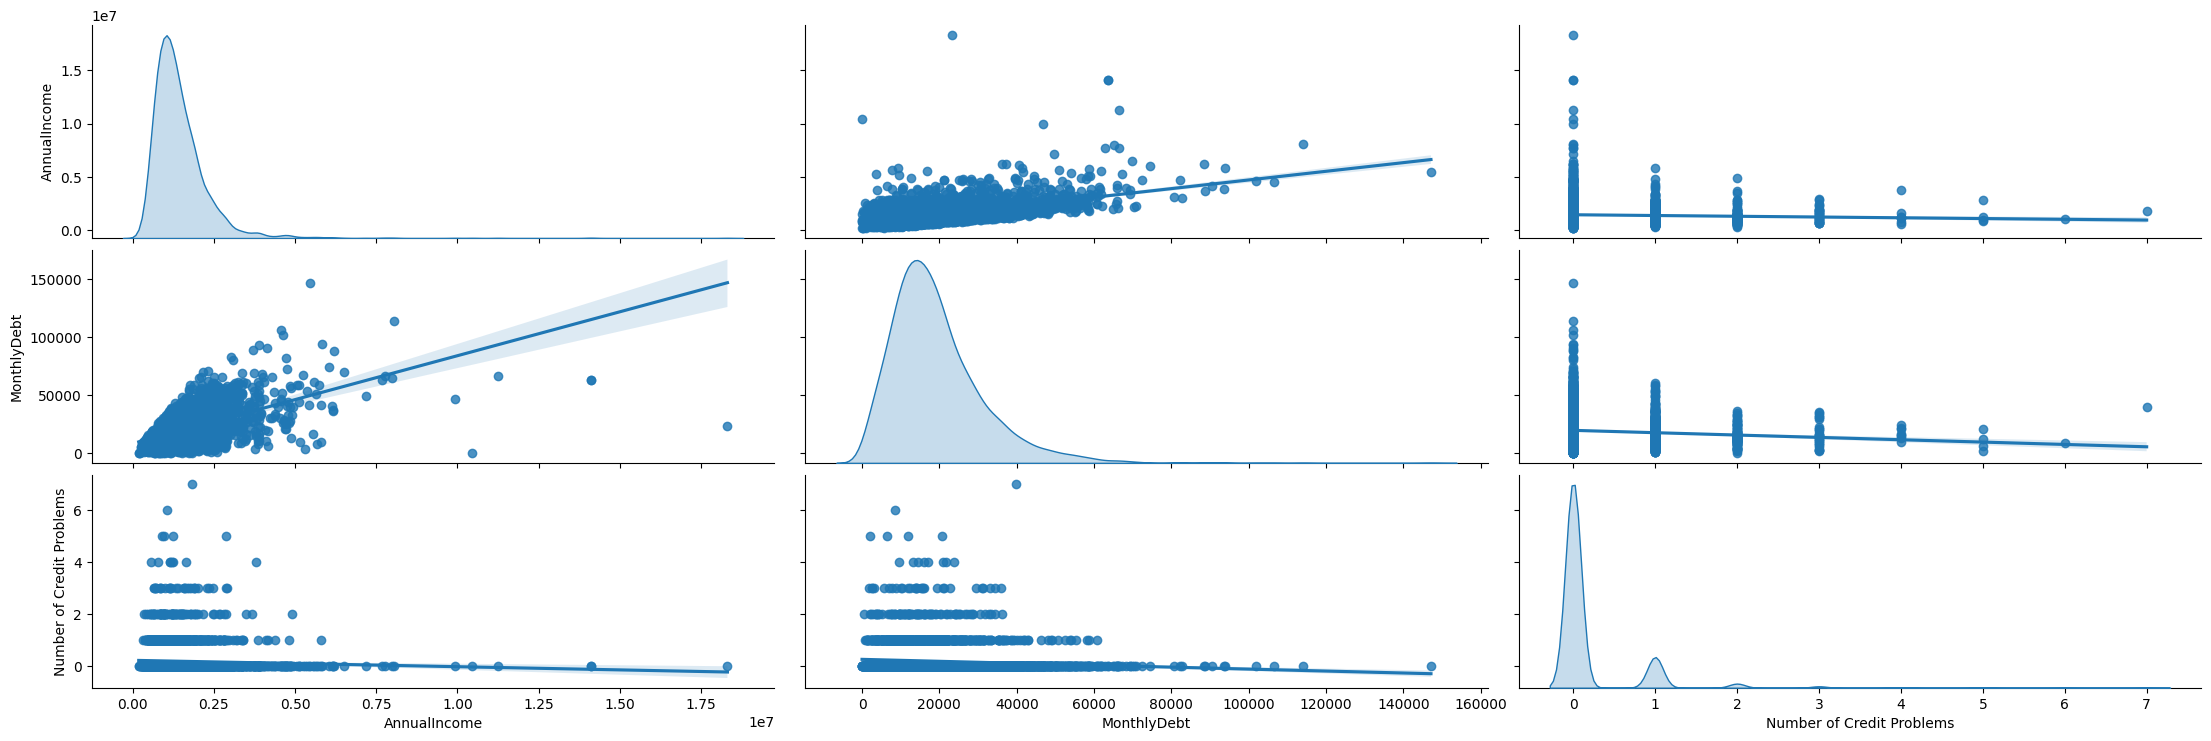

In [28]:
sns.pairplot(credit_data, vars= ['AnnualIncome', 'MonthlyDebt',
                                 'Number of Credit Problems'],
             diag_kind='kde', kind='reg', aspect=3)

In [29]:
#DEBUGGING 
#credit_data.dtypes

#cols = ['Years of Credit History', 
#        'Number of Credit Problems',
#        'Current Credit Balance']

#credit_data[cols] = credit_data[cols].apply(pd.to_numeric, errors='coerce')

#credit_data = credit_data.dropna(subset=cols)


#for c in cols:
#    print(c, credit_data[c].dtype)
    
#credit_data[cols].isna().sum()
#np.isinf(credit_data[cols]).sum()

#credit_data[cols].nunique()



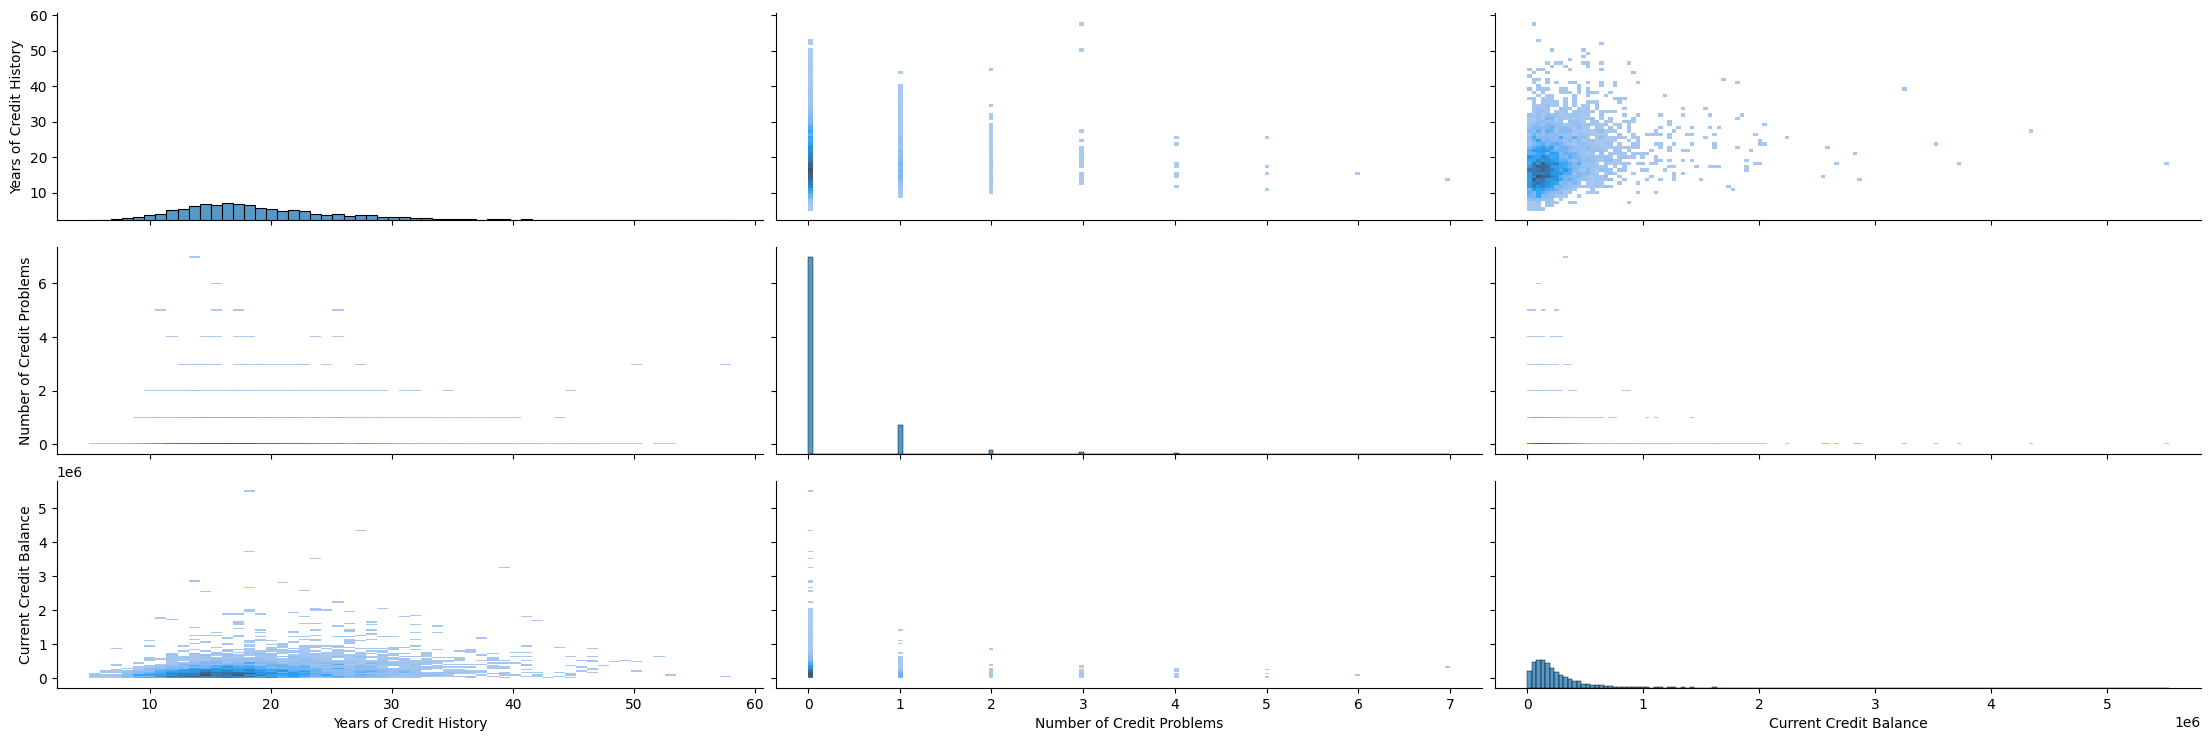

In [33]:
sns.pairplot(credit_data, vars=['Years of Credit History','Number of Credit Problems','Current Credit Balance'],
             kind='hist', aspect=3)

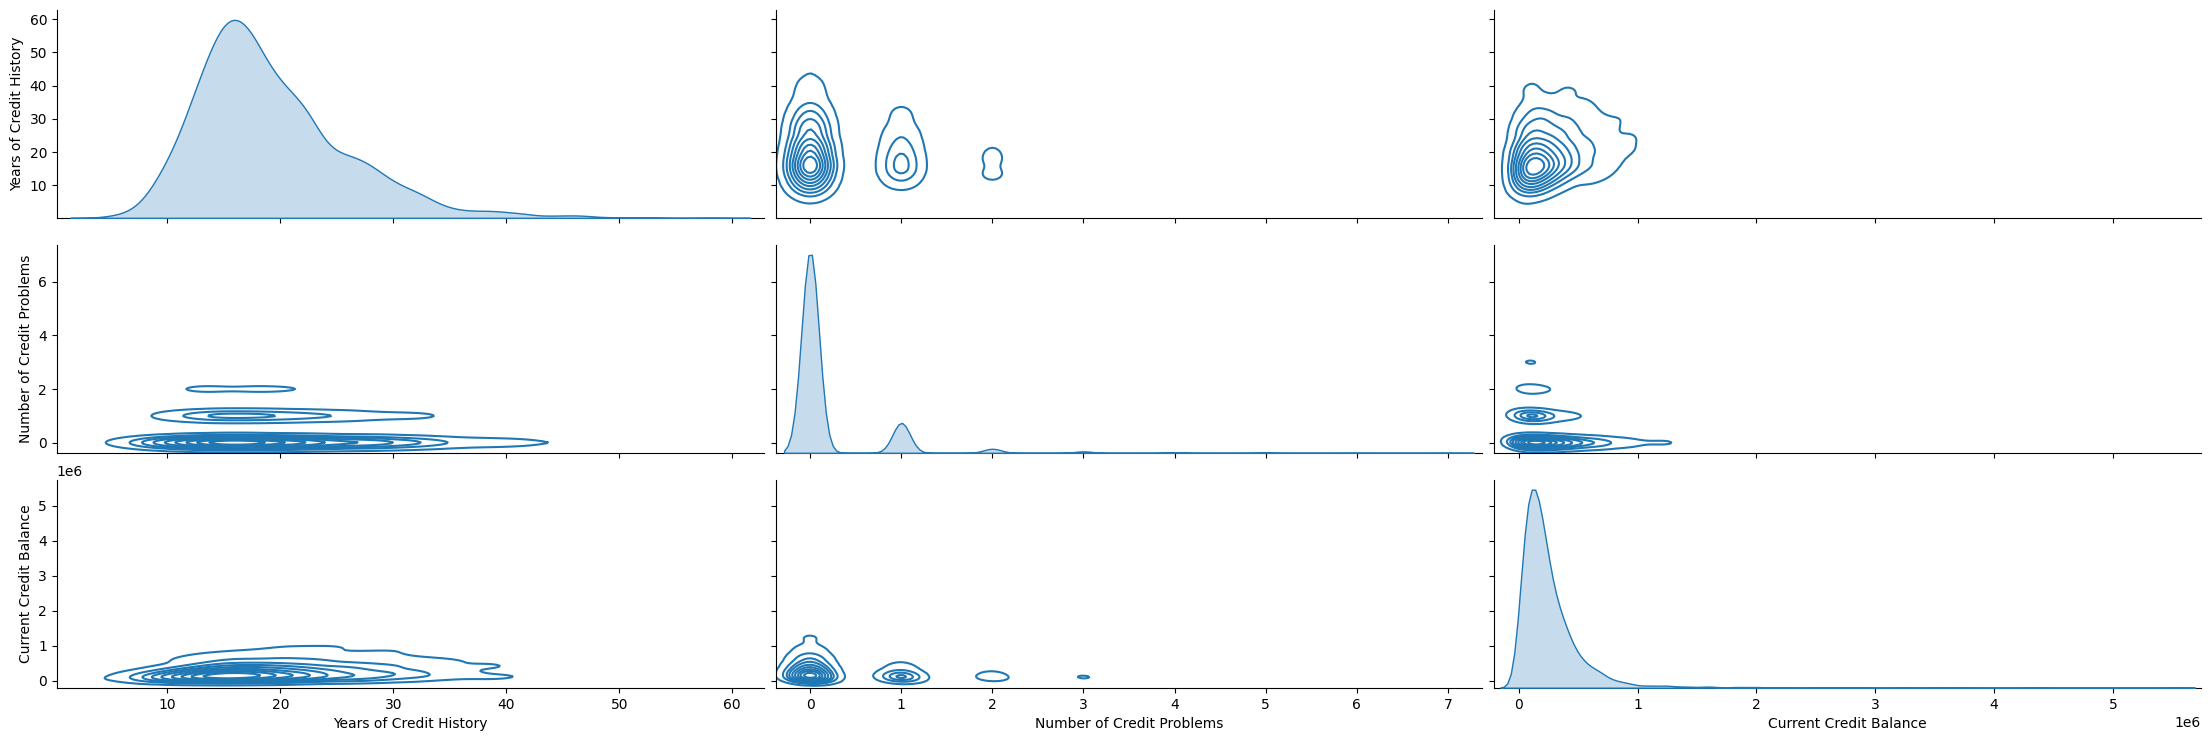

In [32]:
sns.pairplot(credit_data, vars=['Years of Credit History',
                                'Number of Credit Problems', 'Current Credit Balance'],
             kind='kde', aspect=3)

In [37]:
# Use the describe method to flush out if something is a object rather than a numeric value
credit_data['Current Credit Balance'].describe()




count    5.000000e+03
mean     2.596902e+05
std      2.842313e+05
min      0.000000e+00
25%      1.016642e+05
50%      1.863995e+05
75%      3.262538e+05
max      5.535479e+06
Name: Current Credit Balance, dtype: float64

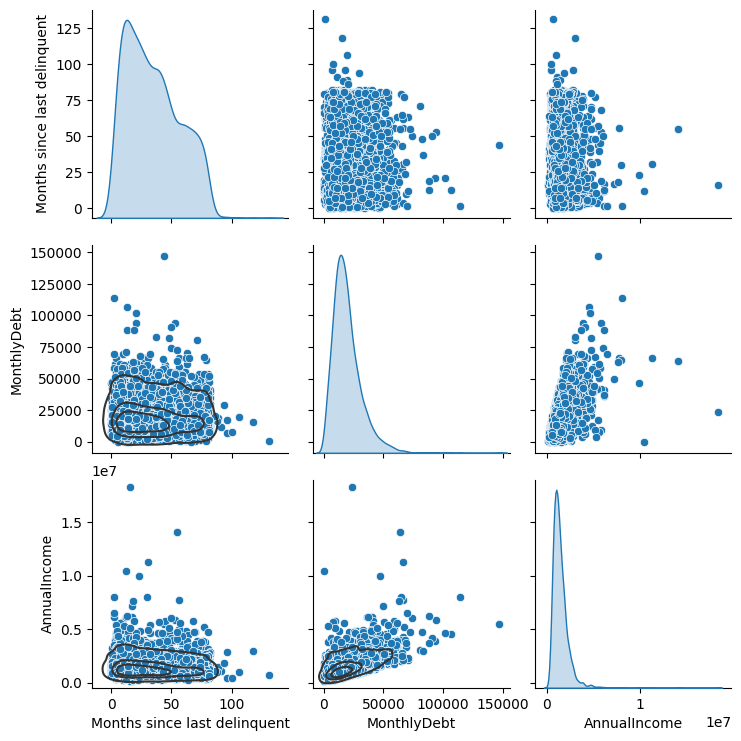

In [39]:
g = sns.pairplot(credit_data, vars =['Months since last delinquent',
                                    'MonthlyDebt', 'AnnualIncome'],
                diag_kind = 'kde')

g.map_lower(sns.kdeplot, levels = 4, color = '.2')

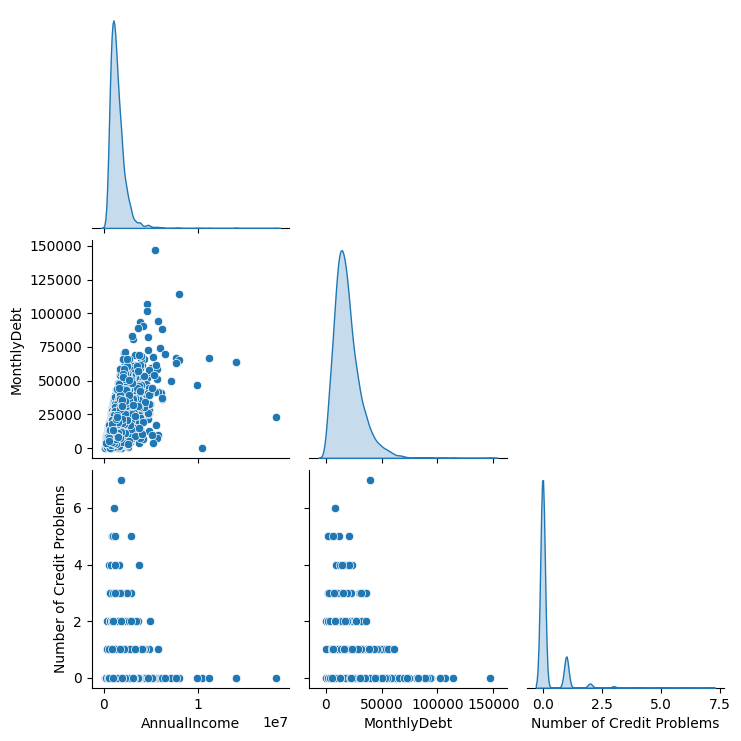

In [40]:
sns.pairplot(credit_data, vars=['AnnualIncome', 'MonthlyDebt', 'Number of Credit Problems'],
            diag_kind='kde', corner=True)

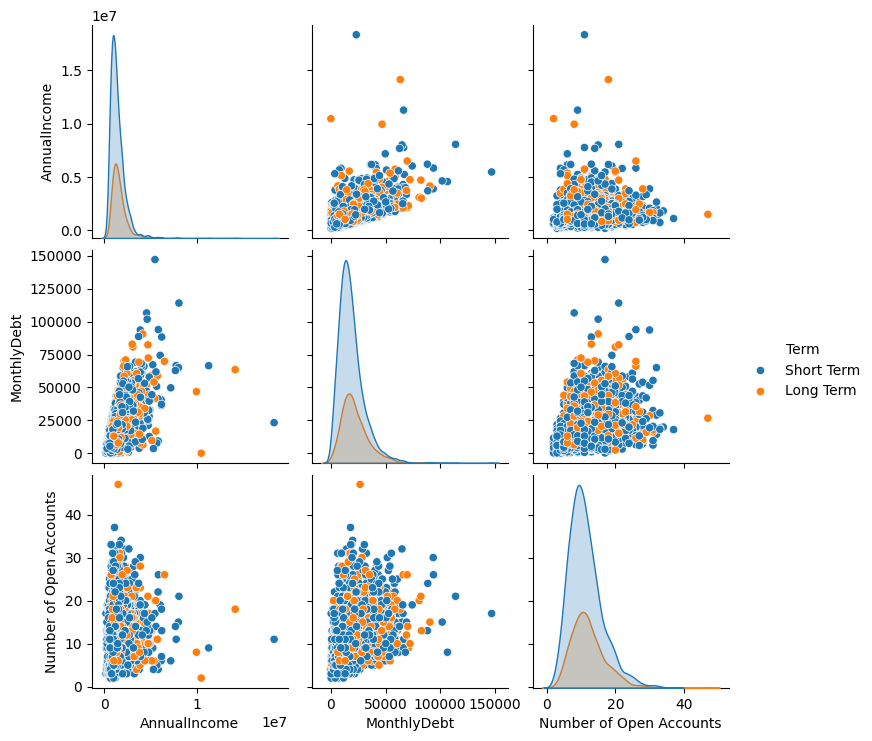

In [41]:
sns.pairplot(credit_data, vars=['AnnualIncome', 'MonthlyDebt', 'Number of Open Accounts'],
            diag_kind='kde', hue='Term')